In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from IPython.display import Image as IPImage
from PIL import Image

In [2]:
def mhd_2d_reconnection_frames(J, K, N, P, dt_out = 0.5):
    """
    Generates snapshots of solution of 2D MHD equations.

    Parameters
    ----------
    J : int
        Number of grid cells in x-direction per processor
    K : int
        Total number of grid cells in y-direction
    N : int
        Total number of outputs generated by CentPack
    P : int
        Number of processors used in the simulation
    """

    os.chdir('/Users/evandaniels/Research/CentPackL/simulation_MHD2d_reconnection_SD2')

    y = np.loadtxt('mesh_files/y')

    x = np.array([])
    for p in range(P):
        x_file = f'mesh_files/x_p{p:03d}'
        xp = np.loadtxt(x_file)
        x = np.concatenate([x, xp])

    sub_sample = 16

    xx = x[::sub_sample]
    yy = y[::sub_sample]

    rho_check = []
    for p in range(P):
        rho_check.append(np.loadtxt(f'rho_files/rho_p{p:03d}_000'))
    rho_check = np.vstack(rho_check)
    print(f'rho at n=0: min={rho_check.min():.4f}, max={rho_check.max():.4f}')
    print(f'x range: {x.min():.2f} to {x.max():.2f}')
    print(f'y range: {y.min():.2f} to {y.max():.2f}')

    for n in range(N):

        t = n * dt_out

        rho = []
        u1  = []
        u3  = []
        b1  = []
        b3  = []
        press = []

        for p in range(P):
            rho.append(np.loadtxt(f'rho_files/rho_p{p:03d}_{n:03d}'))
            u1.append( np.loadtxt(f'u1_files/u1_p{p:03d}_{n:03d}'))
            u3.append( np.loadtxt(f'u3_files/u3_p{p:03d}_{n:03d}'))
            b1.append( np.loadtxt(f'b1_files/b1_p{p:03d}_{n:03d}'))
            b3.append( np.loadtxt(f'b3_files/b3_p{p:03d}_{n:03d}'))
            press.append(np.loadtxt(f'p_files/p_p{p:03d}_{n:03d}'))

        rho   = np.vstack(rho)
        u1    = np.vstack(u1)
        u3    = np.vstack(u3)
        b1    = np.vstack(b1)
        b3    = np.vstack(b3)
        press = np.vstack(press)

        ux = u1[::sub_sample, ::sub_sample]
        uy = u3[::sub_sample, ::sub_sample]
        bx = b1[::sub_sample, ::sub_sample]
        by = b3[::sub_sample, ::sub_sample]

        if n > 0:
            fig, ax = plt.subplots()
            # cf = ax.contourf(x, y, rho.T, levels=np.linspace(0, 10, 20), vmin=0, vmax=10)
            cf = ax.contourf(x, y, rho.T, 20)  # let it autoscale
            fig.colorbar(cf, ax=ax, label='Density')
            # ax.contourf(x, y, rho.T, 20)
            ax.set_title(f't = {t:.2f}')
            ax.set_aspect('equal')
            fig.savefig(f'rho_frames/rho_{n:03d}.png', dpi=100)
            plt.close(fig)

        # fig, ax = plt.subplots()
        # # ax.quiver(xx, yy, ux.T, uy.T, scale=1/1.5)
        # ax.quiver(xx, yy, ux.T, uy.T)
        # ax.set_xlim(-9.8, 9.8); ax.set_ylim(-9.8, 9.8)
        # ax.set_title(f't = {t:.2f}')
        # ax.set_aspect('equal')
        # fig.savefig(f'u_frames/u_{n:03d}.png', dpi=100)
        # plt.close(fig)

        # fig, ax = plt.subplots()
        # # ax.streamplot(xx, yy, bx.T, by.T, density=2, color='black', linewidth=0.5)
        # ax.streamplot(xx, yy, bx.T, by.T, density=1, color='black', linewidth=0.8)
        # ax.set_xlim(-9.8, 9.8); ax.set_ylim(-9.8, 9.8)
        # ax.set_title(f't = {t:.2f}')
        # ax.set_aspect('equal')
        # fig.savefig(f'b_frames/b_{n:03d}.png', dpi=100)
        # plt.close(fig)

        fig, ax = plt.subplots()
        # cf = ax.contourf(x, y, press.T, levels=np.linspace(0, 10, 20), vmin=0, vmax=9)
        cf = ax.contourf(x, y, press.T, 20)  # let it autoscale
        fig.colorbar(cf, ax=ax, label='Pressure')
        # ax.contourf(x, y, press.T, 20)
        ax.set_xlim(-9.8, 9.8); ax.set_ylim(-9.8, 9.8)
        ax.set_title(f't = {t:.2f}')
        ax.set_aspect('equal')
        fig.savefig(f'p_frames/p_{n:03d}.png', dpi=100)
        plt.close(fig)

        # Current density
        dx = x[1] - x[0]
        dy = y[1] - y[0]
        jz = np.gradient(b1, axis=1) / dy - np.gradient(b3, axis=0) / dx
        fig, ax = plt.subplots()
        cf = ax.contourf(x, y, jz.T, 20, cmap='RdBu_r')
        fig.colorbar(cf, ax=ax, label='Jz')
        ax.streamplot(xx, yy, bx.T, by.T, density=1, color='black', linewidth=0.8)
        ax.set_xlim(-9.8, 9.8); ax.set_ylim(-9.8, 9.8)
        ax.set_title(f't = {t:.2f}')
        ax.set_aspect('equal')
        fig.savefig(f'jz_frames/jz_{n:03d}.png', dpi=100)
        plt.close(fig)

        # Bz out of plane
        fig, ax = plt.subplots()
        cf = ax.contourf(x, y, b3.T, 20, cmap='RdBu_r')
        fig.colorbar(cf, ax=ax, label='Bz')
        ax.set_xlim(-9.8, 9.8); ax.set_ylim(-9.8, 9.8)
        ax.set_title(f't = {t:.2f}')
        ax.set_aspect('equal')
        fig.savefig(f'bz_frames/bz_{n:03d}.png', dpi=100)
        plt.close(fig)

        # B field lines on density
        fig, ax = plt.subplots()
        cf = ax.contourf(x, y, rho.T, 20, cmap='Blues_r')
        fig.colorbar(cf, ax=ax, label='Density')
        ax.streamplot(xx, yy, bx.T, by.T, density=1, color='black', linewidth=0.8)
        ax.set_xlim(-9.8, 9.8); ax.set_ylim(-9.8, 9.8)
        ax.set_title(f't = {t:.2f}')
        ax.set_aspect('equal')
        fig.savefig(f'b_on_rho_frames/b_on_rho_{n:03d}.png', dpi=100)
        plt.close(fig)

        print(f'Frame {n+1}/{N} done')

In [4]:
mhd_2d_reconnection_frames(80, 638, 52, 8) # J, K, N, P

rho at n=0: min=0.5000, max=1.5000
x range: -9.78 to 9.78
y range: -9.78 to 9.78
Frame 1/52 done


FileNotFoundError: rho_files/rho_p000_001 not found.

In [ ]:
def frames_to_gif(frame_dir, output_name, duration=100):
    frames = sorted(glob.glob(f'{frame_dir}/*.png'))
    images = [Image.open(f) for f in frames]
    images[0].save(
        output_name,
        save_all=True,
        append_images=images[1:],
        loop=0,
        duration=duration  # milliseconds per frame
    )

frames_to_gif('rho_frames', 'rho.gif')
# frames_to_gif('u_frames',  'u.gif')
frames_to_gif('p_frames',   'p.gif')
# frames_to_gif('b_frames',   'b.gif')
frames_to_gif('jz_frames', 'jz.gif')
frames_to_gif('bz_frames', 'bz.gif')
frames_to_gif('b_on_rho_frames', 'b_rho.gif')

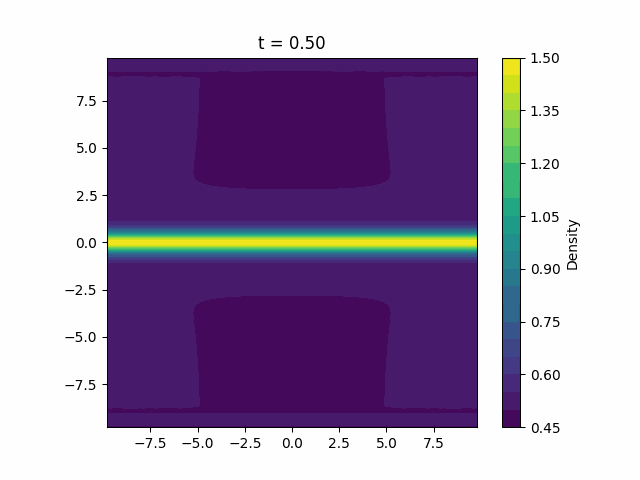

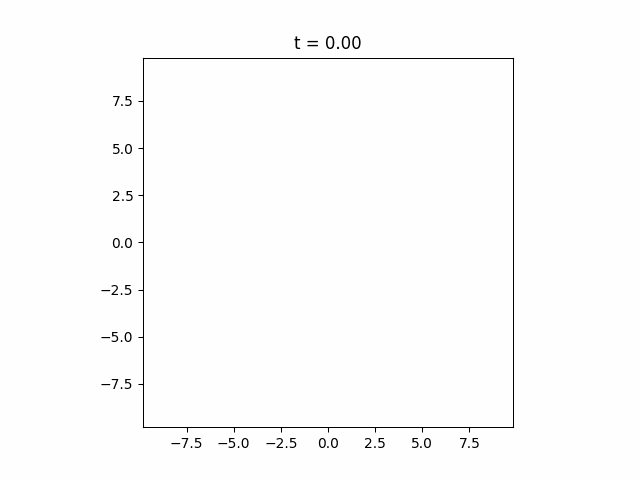

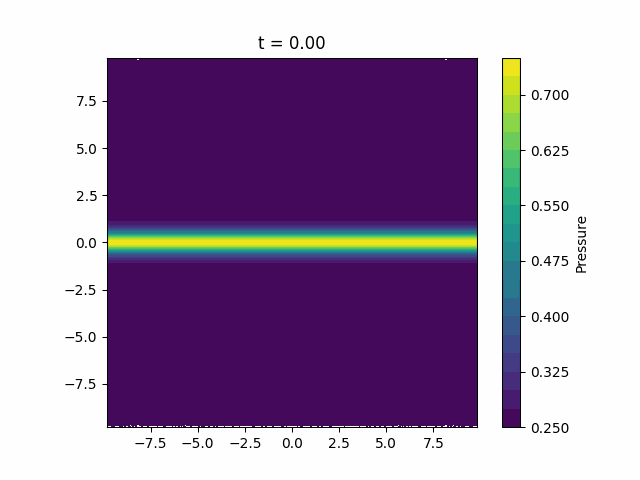

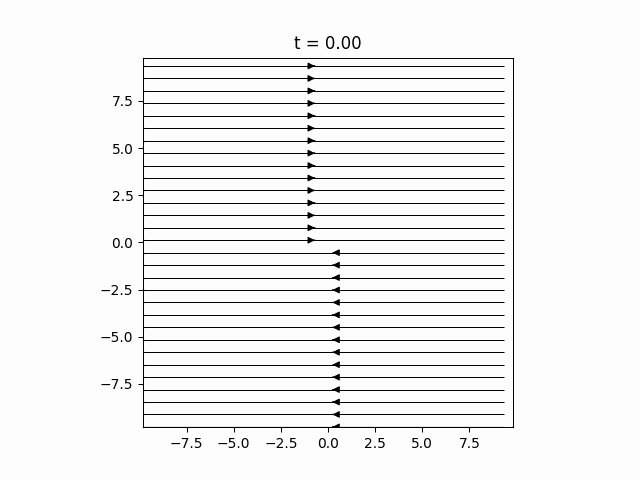

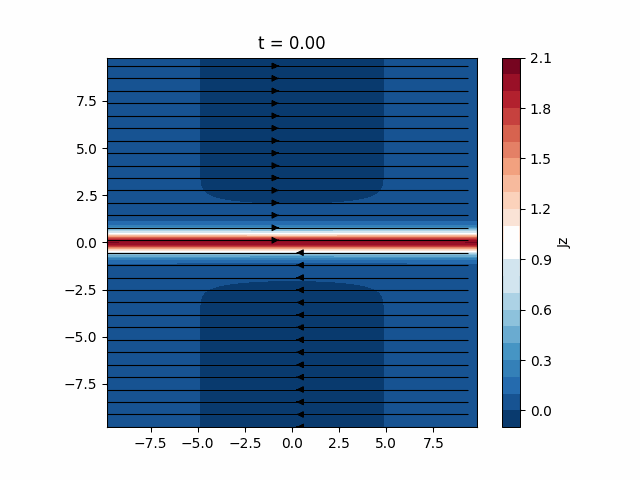

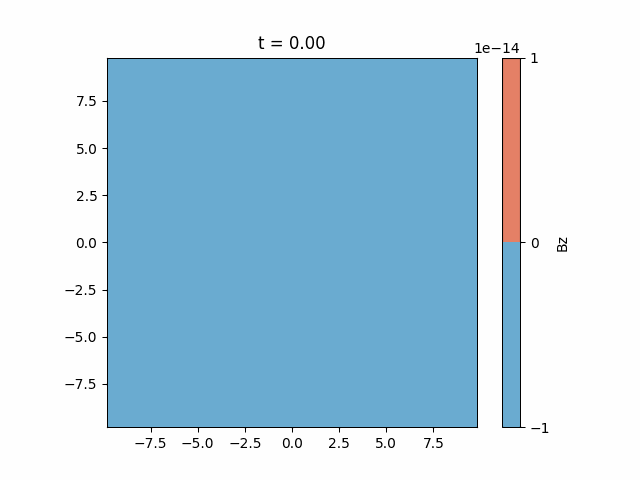

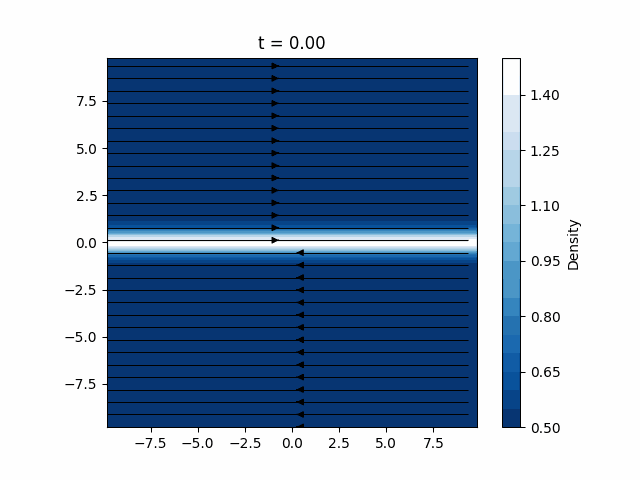

In [ ]:
display(IPImage('rho.gif'))
display(IPImage('u.gif'))
display(IPImage('p.gif'))
display(IPImage('b.gif'))
display(IPImage('jz.gif'))
display(IPImage('bz.gif'))
display(IPImage('b_rho.gif'))

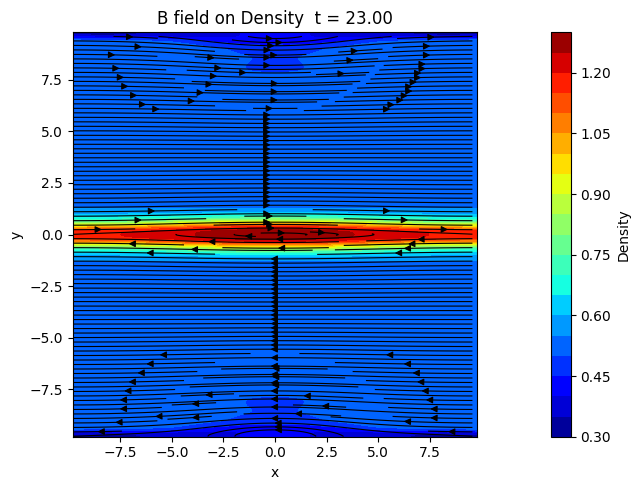

In [ ]:
def plot_reconnection_snapshot(J, K, P, n, dt_out=0.5):
    """Plot a single frame matching Figure 2 right panel of Qian et al."""
    
    os.chdir('/Users/evandaniels/Research/CentPackL/simulation_MHD2d_reconnection_SD2')

    y = np.loadtxt('mesh_files/y')
    x = np.array([])
    for p in range(P):
        xp = np.loadtxt(f'mesh_files/x_p{p:03d}')
        x = np.concatenate([x, xp])

    rho, b1, b3 = [], [], []
    for p in range(P):
        rho.append(np.loadtxt(f'rho_files/rho_p{p:03d}_{n:03d}'))
        b1.append(np.loadtxt(f'b1_files/b1_p{p:03d}_{n:03d}'))
        b3.append(np.loadtxt(f'b3_files/b3_p{p:03d}_{n:03d}'))

    rho = np.vstack(rho)
    b1  = np.vstack(b1)
    b3  = np.vstack(b3)

    sub_sample = 8
    xx = x[::sub_sample]
    yy = y[::sub_sample]
    bx = b1[::sub_sample, ::sub_sample]
    by = b3[::sub_sample, ::sub_sample]

    t = n * dt_out

    fig, ax = plt.subplots(figsize=(15, 5))
    cf = ax.contourf(x, y, rho.T, 20, cmap='jet', vmin=0.3, vmax=1.3)
    fig.colorbar(cf, ax=ax, label='Density')
    ax.streamplot(xx, yy, bx.T, by.T, density=3, color='black', linewidth=0.8)
    ax.set_xlim(-9.8, 9.8)
    ax.set_ylim(-9.8, 9.8)
    ax.set_title(f'B field on Density  t = {t:.2f}', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.savefig(f'b_on_rho_frames/reconnection_{n:03d}.png', dpi=150)
    plt.show()

plot_reconnection_snapshot(80, 638, 8, n=46, dt_out=0.5)  # n=46 → t=23